In [123]:
import requests
import csv

url = "https://raw.githubusercontent.com/BDonadelli/Finance-playground/main/data/Cart_IBr50.csv"

response = requests.get(url)
response.encoding = 'utf-8'  # ou 'latin-1' se necessário

# Divide o conteúdo em linhas
linhas = response.text.splitlines()

# Ignora as duas primeiras e duas últimas linhas
linhas_filtradas = linhas[2:-2]

# Extrai a primeira coluna de cada linha restante
papeis = []
for linha in linhas_filtradas:
    # O separador é ";", pega o primeiro campo
    campos = linha.split(';')
    if campos:  # garante que a linha não está vazia
        papeis.append((campos[0],float(campos[4].replace(',','.') )))

papeis.sort()


In [126]:
sorted(papeis, key=lambda x: x[1], reverse=True)

[('VALE3', 13.458),
 ('ITUB4', 8.744),
 ('PETR4', 8.016),
 ('PETR3', 6.972),
 ('AXIA3', 4.418),
 ('SBSP3', 4.193),
 ('BBDC4', 3.685),
 ('B3SA3', 3.646),
 ('ITSA4', 3.137),
 ('BPAC11', 3.037),
 ('WEGE3', 2.822),
 ('BBAS3', 2.509),
 ('ABEV3', 2.465),
 ('EMBJ3', 2.209),
 ('PRIO3', 1.949),
 ('EQTL3', 1.912),
 ('ENEV3', 1.796),
 ('CPLE3', 1.784),
 ('RENT3', 1.758),
 ('RDOR3', 1.639),
 ('VBBR3', 1.417),
 ('UGPA3', 1.182),
 ('SUZB3', 1.176),
 ('VIVT3', 1.151),
 ('AXIA7', 1.123),
 ('RADL3', 1.082),
 ('GGBR4', 0.945),
 ('BBDC3', 0.928),
 ('CMIG4', 0.917),
 ('BBSE3', 0.824),
 ('TIMS3', 0.824),
 ('RAIL3', 0.742),
 ('ENGI11', 0.719),
 ('TOTS3', 0.705),
 ('MOTV3', 0.612),
 ('MBRF3', 0.602),
 ('KLBN11', 0.578),
 ('LREN3', 0.55),
 ('ASAI3', 0.461),
 ('MULT3', 0.387),
 ('CSAN3', 0.365),
 ('BRAV3', 0.358),
 ('PSSA3', 0.345),
 ('SMFT3', 0.337),
 ('NATU3', 0.327),
 ('CYRE3', 0.266),
 ('COGN3', 0.23),
 ('CSNA3', 0.178),
 ('POMO4', 0.17),
 ('MGLU3', 0.123),
 ('HAPV3', 0.115),
 ('RENT4', 0.065),
 ('CYRE4', 

In [145]:
valor = ['ITUB4' , 'PSSA3' , 'MOTV3' , 'VIVT3' , 'SBSP3' , 'CMIG4' , 'MULT3']
cresc = ['WEGE3' , 'RADL3' , 'TOTS3' , 'RDOR3' , 'LREN3' , 'PRIO3' , 'COGN3']
cicli = ['GGBR4' , 'KLBN4' , 'MBRF3' , 'CYRE3' , 'POMO4' , 'UGPA3' , 'VBBR3']
papeis = valor + cresc + cicli
papeis.sort()


In [146]:
import pandas as pd
url = 'https://raw.githubusercontent.com/BDonadelli/Finance-playground/main/data/SI_Acoes.csv'
tabela = pd.read_csv(url,sep=';' , decimal=',' , thousands='.')
tabela.head(2)

,TICKER,PRECO,DY,P/L,P/VP,P/ATIVOS,MARGEM BRUTA,MARGEM EBIT,MARG. LIQUIDA,P/EBIT,...,PATRIMONIO / ATIVOS,PASSIVOS / ATIVOS,GIRO ATIVOS,CAGR RECEITAS 5 ANOS,CAGR LUCROS 5 ANOS,LIQUIDEZ MEDIA DIARIA,VPA,LPA,PEG Ratio,VALOR DE MERCADO
0,AALR3,3.99,NaN,-7.55,0.57,0.2,26.83,9.47,-6.49,5.18,...,0.35,0.64,0.41,2.55,NaN,341713.82,7.00,-0.53,0.15,6.079143e+08
1,ABCB4,26.03,10.06,6.36,0.94,0.1,19.54,14.15,11.82,5.31,...,0.11,0.89,0.13,28.96,24.08,12732473.95,27.63,4.10,2.01,6.368418e+09


In [147]:
## usar uma porcentagem do cagr 5y dos lucros como proxy de retorno futuro
projetado = tabela.loc[tabela['TICKER'].isin(papeis)][['TICKER' , 'CAGR LUCROS 5 ANOS']].set_index('TICKER').fillna(0)/111
projetado.rename(columns={'CAGR LUCROS 5 ANOS' : 'ret_projetado'},inplace=True)
projetado

,ret_projetado
TICKER,
CMIG4,0.102072
COGN3,0.000000
CYRE3,0.023964
GGBR4,-0.091261
ITUB4,0.170090
KLBN4,0.000000
LREN3,0.052793
MBRF3,-0.323153
MOTV3,0.689910


In [148]:
periodo = '5y'
intervalo = '1d'
ponto = 'Close'

# parametros  para anualização
n_dias = 252

ativos = projetado.index.to_list()
n_ativos = len(ativos)

retorno_anual = projetado.copy()

In [149]:
import yfinance as yf

# Download preços do yahoo finance
dados = yf.download( [tck+'.SA' for tck in ativos],
                    interval=intervalo,
                    auto_adjust=True,
                    progress=False )[ponto]

dados.columns = dados.columns.str.rstrip('.SA')
dados.index = dados.index.date
dados

Ticker,CMIG4,COGN3,CYRE3,GGBR4,ITUB4,KLBN4,LREN3,MBRF3,MOTV3,MULT3,...,PRIO3,PSSA3,RADL3,RDOR3,SBSP3,TOTS3,UGPA3,VBBR3,VIVT3,WEGE3
2026-03-10,11.678201,3.21,28.520000,18.750000,43.422958,3.94,15.003836,17.200001,16.020000,32.048786,...,58.900002,48.584003,23.646587,38.599274,147.064209,36.940079,26.950001,31.317801,42.026249,47.087200
2026-03-11,11.629133,3.18,28.530001,18.670000,43.512184,3.95,15.457303,16.469999,15.950000,31.672323,...,59.349998,48.175903,23.855762,38.270645,146.766327,37.377827,27.090000,31.208956,41.237442,46.777878
2026-03-12,11.462302,2.96,27.520000,18.030001,42.322510,3.85,14.806677,16.990000,15.080000,30.681635,...,59.500000,47.554024,23.556942,37.105495,143.221542,35.925293,26.049999,28.873726,40.418686,45.720184
2026-03-13,11.501556,2.95,26.580000,17.730000,42.035011,3.83,14.846108,16.900000,14.870000,29.641413,...,57.799999,47.913551,23.487217,36.448231,144.115189,34.413071,26.120001,29.081522,40.578442,46.109333
2026-03-16,11.727269,2.98,26.990000,17.799999,42.629845,3.85,14.984119,16.830000,15.250000,30.364614,...,59.799999,45.999336,23.268084,36.886410,144.591797,34.940357,25.940001,29.516903,40.528519,45.869858
2026-03-17,11.697828,2.92,27.400000,17.660000,42.342339,3.85,14.905255,16.620001,15.190000,30.562754,...,62.689999,46.640648,23.327847,37.015869,148.444397,34.502609,26.430000,30.229345,40.927914,46.099358
2026-03-18,11.589879,2.85,27.299999,17.389999,41.916042,3.80,14.875682,17.030001,15.150000,30.334896,...,66.029999,46.300560,23.088791,36.866493,146.210297,33.607212,26.219999,29.487217,40.568459,46.059444
2026-03-19,11.962795,2.83,27.110001,17.490000,42.213459,3.78,14.934830,17.059999,15.120000,30.483498,...,65.820000,47.126488,23.019068,37.015869,151.740967,33.975323,26.780001,29.813753,40.768158,46.488506
2026-03-20,12.011864,2.81,25.049999,17.450001,41.532623,3.70,14.629232,16.600000,14.770000,29.641413,...,67.889999,46.106220,22.391544,37.075619,148.500000,33.786289,26.160000,28.784672,40.209003,45.859879
2026-03-23,12.227764,2.97,27.219999,18.000000,42.762108,3.82,15.437586,18.980000,15.530000,31.196795,...,65.959999,47.777508,23.188398,38.738697,152.539993,34.870716,27.420000,30.249136,40.408703,47.250000


<Axes: xlabel='Ticker'>

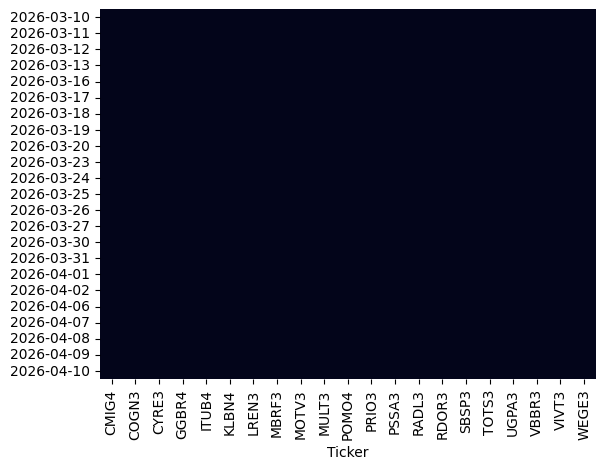

In [150]:
import seaborn as sns
sns.heatmap(dados.isnull(),cbar=False)

In [151]:
# retorno histórico, tb usado coo proxy de retorno futuro
retornos = (dados.pct_change()).dropna()
retorno_anual['ret_historico']= retornos.mean()*n_dias

In [152]:
retorno_anual

,ret_projetado,ret_historico
TICKER,,
CMIG4,0.102072,1.952162
COGN3,0.000000,0.060253
CYRE3,0.023964,-0.089704
GGBR4,-0.091261,1.509739
ITUB4,0.170090,0.718915
KLBN4,0.000000,-0.317149
LREN3,0.052793,0.622017
MBRF3,-0.323153,1.831340
MOTV3,0.689910,0.712604


In [153]:
import numpy as np

#Volatilidade = dp retorno diário
riscos = retornos.std().dropna()
# volatilidade anualizada
vol_ano = riscos*np.sqrt(n_dias)
#covariancia anualizada
matriz_covarianca_ano = retornos.cov()*n_dias

In [154]:
matriz_covarianca_ano

Ticker,CMIG4,COGN3,CYRE3,GGBR4,ITUB4,KLBN4,LREN3,MBRF3,MOTV3,MULT3,...,PRIO3,PSSA3,RADL3,RDOR3,SBSP3,TOTS3,UGPA3,VBBR3,VIVT3,WEGE3
Ticker,,,,,,,,,,,,,,,,,,,,,
CMIG4,0.051296,0.050151,0.067061,0.040213,0.050298,0.035481,0.052227,-0.013332,0.061050,0.057768,...,-0.053090,0.034162,0.043186,0.042989,0.053905,0.039322,0.021803,0.054518,0.032592,0.034625
COGN3,0.050151,0.200820,0.193388,0.118000,0.103063,0.093779,0.132954,0.015378,0.127049,0.128402,...,-0.144729,0.062565,0.060339,0.090178,0.065268,0.096129,0.067122,0.116740,0.057214,0.082657
CYRE3,0.067061,0.193388,0.418533,0.151715,0.145407,0.151542,0.165997,0.072743,0.180576,0.214823,...,-0.171553,0.110970,0.144051,0.124398,0.122932,0.110753,0.087753,0.151402,0.090821,0.123595
GGBR4,0.040213,0.118000,0.151715,0.106395,0.073742,0.061263,0.091070,-0.023926,0.089110,0.099347,...,-0.090068,0.053337,0.043521,0.066184,0.057191,0.056578,0.046677,0.079308,0.053535,0.051466
ITUB4,0.050298,0.103063,0.145407,0.073742,0.084921,0.066366,0.098460,-0.014925,0.094554,0.103862,...,-0.109523,0.052065,0.069465,0.065999,0.064429,0.062360,0.035829,0.074369,0.053129,0.064967
KLBN4,0.035481,0.093779,0.151542,0.061263,0.066366,0.077308,0.079526,0.035931,0.082787,0.084625,...,-0.078173,0.047320,0.060496,0.052675,0.057311,0.050838,0.032640,0.071213,0.043879,0.056188
LREN3,0.052227,0.132954,0.165997,0.091070,0.098460,0.079526,0.184634,-0.010900,0.114837,0.118453,...,-0.138129,0.061027,0.089246,0.076839,0.068193,0.081956,0.053435,0.095807,0.060495,0.059874
MBRF3,-0.013332,0.015378,0.072743,-0.023926,-0.014925,0.035931,-0.010900,0.430984,0.030390,0.022834,...,0.038410,0.032714,0.038439,0.020483,0.002674,0.017949,0.045951,0.044636,-0.024077,0.025762
MOTV3,0.061050,0.127049,0.180576,0.089110,0.094554,0.082787,0.114837,0.030390,0.136893,0.127751,...,-0.079664,0.060634,0.067532,0.091099,0.076693,0.079263,0.063273,0.116804,0.057142,0.068175


### ***otimização***

In [155]:
# caclula a volatilidade (aa) da carteira dada pelos pesos p
def volatilidade( p ):
  '''
  volatilidade da carteira definida por pesos p
  '''
  return  np.sqrt(np.dot(p.T,np.dot(matriz_covarianca_ano,p)))

# calcula a retorno esperado da carteira dada pelos pesos p
def retorno_esperado( p , tipo='projetado'):
  '''
  retorno da carteira definida por pesos p
  '''
  if tipo == 'projetado' : retornos = retorno_anual['ret_projetado']
  else : retornos = retorno_anual['ret_historico']

  return np.dot(retornos , p )

# a biblioteca de otimização tem um metodo de *minimização*
# para maximizar a função f calculamos o minimo de -f
def neg_ratio ( p , tipo='projetado', rf=0.0) :
  sharpe = (retorno_esperado(p,tipo) - rf)/ volatilidade(p)
  return -sharpe


#### **carteira com a melhor razão retorno/risco**
**considerando que $\text{peso}$ é limitado inferiormente e superiomente e que as açoes de crescimento e cíclicas têm participação total limitada superiormente**


In [192]:
limites   = tuple((0.01,.15) for x in range(n_ativos))    

restricao = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},                ## a soma dos pesos é 1, i.e., np.sum(x) - 1 = 0
    {'type': 'ineq', 'fun' : lambda x: 0.3 -  x[1] - x[6] - x[11] - x[13] - x[14] - x[16] - x[20]  } , ##  cresc <= 30% 
    {'type': 'ineq', 'fun' : lambda x: 0.2 -  x[2] - x[3] - x[5] - x[7] - x[10] - x[17] - x[18]  } ##  cicl <= 20% 
)

In [193]:
import scipy.optimize as scpopt

max_ratio = scpopt.minimize(neg_ratio,        # para max do ratio, calculamos min do -ratio = neg_ratio
                            x0 =  n_ativos * [1. / n_ativos] ,
                            args = 'p' ,
                            method='SLSQP',
                            bounds =  limites,
                            constraints =restricao
                            )

max_ratio_pesos_p = max_ratio['x']
print(max_ratio['message'])

Optimization terminated successfully


In [194]:

max_ratio = scpopt.minimize(neg_ratio,        # para max do ratio, calculamos min do -ratio = neg_ratio
                            x0 =  n_ativos * [1. / n_ativos] ,
                            args = 'h' ,
                            method='SLSQP',
                            bounds =  limites,
                            constraints =restricao
                            )

max_ratio_pesos_h = max_ratio['x']
print(max_ratio['message'])

Optimization terminated successfully


projetado

In [195]:
max_ratio_r = np.round( retorno_esperado(max_ratio_pesos_p,'p') ,4)
max_ratio_v = np.round( volatilidade(max_ratio_pesos_p),4)
max_ratio_s = np.round( -max_ratio['fun'],4)

# resultado
for x, y in zip(ativos, max_ratio_pesos_p):
  print(f'{x}: {100*y:.2f}%')
print('')
print('Retorno esperado %.2f' %(max_ratio_r*100)+'%')
print('Volatilidade %.2f' %(max_ratio_v*100)+'%')

CMIG4: 15.00%
COGN3: 1.00%
CYRE3: 1.00%
GGBR4: 8.60%
ITUB4: 2.00%
KLBN4: 1.00%
LREN3: 1.00%
MBRF3: 6.40%
MOTV3: 1.00%
MULT3: 1.00%
POMO4: 1.00%
PRIO3: 15.00%
PSSA3: 15.00%
RADL3: 1.00%
RDOR3: 1.00%
SBSP3: 15.00%
TOTS3: 1.00%
UGPA3: 1.00%
VBBR3: 1.00%
VIVT3: 1.00%
WEGE3: 10.00%

Retorno esperado 142.90%
Volatilidade 17.29%


historico

In [196]:
max_ratio_r = np.round( retorno_esperado(max_ratio_pesos_h,'h') ,4)
max_ratio_v = np.round( volatilidade(max_ratio_pesos_h),4)
max_ratio_s = np.round( -max_ratio['fun'],4)

# resultado
for x, y in zip(ativos, max_ratio_pesos_h):
  print(f'{x}: {100*y:.2f}%')
print('')
print('Retorno esperado %.2f' %(max_ratio_r*100)+'%')
print('Volatilidade %.2f' %(max_ratio_v*100)+'%')

CMIG4: 15.00%
COGN3: 1.00%
CYRE3: 1.00%
GGBR4: 8.60%
ITUB4: 2.00%
KLBN4: 1.00%
LREN3: 1.00%
MBRF3: 6.40%
MOTV3: 1.00%
MULT3: 1.00%
POMO4: 1.00%
PRIO3: 15.00%
PSSA3: 15.00%
RADL3: 1.00%
RDOR3: 1.00%
SBSP3: 15.00%
TOTS3: 1.00%
UGPA3: 1.00%
VBBR3: 1.00%
VIVT3: 1.00%
WEGE3: 10.00%

Retorno esperado 142.90%
Volatilidade 17.29%


**limitando a participação de cada ativo**

In [233]:
limites   = tuple((0.0,0.2) for x in range(n_ativos))    
max = scpopt.minimize(neg_ratio, x0 =  n_ativos * [1. / n_ativos] ,args='p',  method='SLSQP',
                            bounds =  limites,
                            constraints =( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )
max_pesos_p = max['x']

max_r = round( retorno_esperado(max_pesos_p, 'p'),4)
max_v = round( volatilidade(max_pesos_p),4)
max_s = round( -max['fun'],4)

# resultado
for x, y in zip(ativos, max_pesos_p):
  if y > 0.01 : #print(y)#
    print(f'{x}: {100*y:.2f}%')
print(' ')
print('Retorno esperado %.2f' %(max_r*100)+'%')
print('Volatilidade %.2f' %(max_v*100)+'%')

CMIG4: 20.00%
GGBR4: 20.00%
MBRF3: 5.17%
PRIO3: 20.00%
PSSA3: 7.52%
UGPA3: 7.31%
WEGE3: 20.00%
 
Retorno esperado 159.68%
Volatilidade 14.29%


In [235]:
max = scpopt.minimize(neg_ratio, x0 =  n_ativos * [1. / n_ativos] ,args='h',  method='SLSQP',
                            bounds =  limites,
                            constraints =( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )
max_pesos_h = max['x']

max_r = round( retorno_esperado(max_pesos_h,'h'),4)
max_v = round( volatilidade(max_pesos_h),4)
max_s = round( -max['fun'],4)

# resultado
for x, y in zip(ativos, max_pesos_h):
  if y > 0.01 : print(f'{x}: {100*y:.2f}%')
print(' ')
print('Retorno esperado %.2f' %(max_r*100)+'%')
print('Volatilidade %.2f' %(max_v*100)+'%')

CMIG4: 20.00%
GGBR4: 20.00%
MBRF3: 5.17%
PRIO3: 20.00%
PSSA3: 7.52%
UGPA3: 7.31%
WEGE3: 20.00%
 
Retorno esperado 159.68%
Volatilidade 14.29%


**com qualquer proporção de ativos**

In [236]:
max = scpopt.minimize(neg_ratio, x0 =  n_ativos * [1. / n_ativos] ,args='p',  method='SLSQP',
                            bounds =  tuple((0,1) for asset in range(n_ativos)),
                            constraints =( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )
max_pesos_p = max['x']

max_r = round( retorno_esperado(max_pesos_p, 'p'),4)
max_v = round( volatilidade(max_pesos_p),4)
max_s = round( -max['fun'],4)

# resultado
for x, y in zip(ativos, max_pesos_p):
  if y > 0.01 : print(f'{x}: {100*y:.2f}%')
print(' ')
print('Retorno esperado %.2f' %(max_r*100)+'%')
print('Volatilidade %.2f' %(max_v*100)+'%')

CMIG4: 43.84%
GGBR4: 7.49%
MBRF3: 2.94%
PRIO3: 22.76%
WEGE3: 22.97%
 
Retorno esperado 173.38%
Volatilidade 13.65%


In [237]:
max = scpopt.minimize(neg_ratio, x0 =  n_ativos * [1. / n_ativos] ,args='h',  method='SLSQP',
                            bounds =  tuple((0,1) for asset in range(n_ativos)),
                            constraints =( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )
max_pesos_h = max['x']

max_r = round( retorno_esperado(max_pesos_h,'h'),4)
max_v = round( volatilidade(max_pesos_h),4)
max_s = round( -max['fun'],4)

# resultado
for x, y in zip(ativos, max_pesos_h):
  if y > 0.01 : print(f'{x}: {100*y:.2f}%')
print(' ')
print('Retorno esperado %.2f' %(max_r*100)+'%')
print('Volatilidade %.2f' %(max_v*100)+'%')

CMIG4: 43.84%
GGBR4: 7.49%
MBRF3: 2.94%
PRIO3: 22.76%
WEGE3: 22.97%
 
Retorno esperado 173.38%
Volatilidade 13.65%


#### **Carteira de menor volatilidade**


**considerando que limitações  de $\text{peso}$ e de tipo crescimento/valor/ciclico**

In [238]:
limites   = tuple((0.01,.15) for x in range(n_ativos))    

restricao = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},                ## a soma dos pesos é 1, i.e., np.sum(x) - 1 = 0
    {'type': 'ineq', 'fun' : lambda x: 0.3 -  x[1] - x[6] - x[11] - x[13] - x[14] - x[16] - x[20]  } , ##  cresc <= 30% 
    {'type': 'ineq', 'fun' : lambda x: 0.2 -  x[2] - x[3] - x[5] - x[7] - x[10] - x[17] - x[18]  } ##  cicl <= 20% 
)

In [239]:
min_vol_P = scpopt.minimize(volatilidade,
                          x0 =  n_ativos * [1. / n_ativos] ,
                          method='SLSQP',
                          bounds = limites ,
                          constraints = restricao)

min_vol_pesos_P = min_vol_P['x']

min_volP_r = round( retorno_esperado(min_vol_pesos_P,'p'),4)
min_volP_v = round( min_vol_P['fun'],4)
min_volP_s = round( -neg_ratio(min_vol_pesos_P),4)

for x, y in zip(ativos, min_vol_pesos_P):
  print(f'{x}: {100*y:.2f}% ')
print(' ')
print('Retorno esperado %.2f' %(100*min_volP_r)+'%')
print('Volatilidade %.2f' %(100*min_volP_v)+'%')

CMIG4: 15.00% 
COGN3: 1.00% 
CYRE3: 1.00% 
GGBR4: 1.00% 
ITUB4: 2.65% 
KLBN4: 5.51% 
LREN3: 1.00% 
MBRF3: 3.92% 
MOTV3: 1.00% 
MULT3: 1.00% 
POMO4: 1.00% 
PRIO3: 15.00% 
PSSA3: 15.00% 
RADL3: 1.00% 
RDOR3: 1.00% 
SBSP3: 1.00% 
TOTS3: 8.71% 
UGPA3: 5.92% 
VBBR3: 1.00% 
VIVT3: 15.00% 
WEGE3: 2.29% 
 
Retorno esperado 94.48%
Volatilidade 15.32%


In [240]:
min_vol_P = scpopt.minimize(volatilidade,
                          x0 =  n_ativos * [1. / n_ativos] ,
                          method='SLSQP',
                          bounds = limites ,
                          constraints = restricao)

min_vol_pesos_P = min_vol_P['x']

min_volP_r = round( retorno_esperado(min_vol_pesos_P,'h'),4)
min_volP_v = round( min_vol_P['fun'],4)
min_volP_s = round( -neg_ratio(min_vol_pesos_P),4)

for x, y in zip(ativos, min_vol_pesos_P):
  print(f'{x}: {100*y:.2f}% ')
print(' ')
print('Retorno esperado %.2f' %(100*min_volP_r)+'%')
print('Volatilidade %.2f' %(100*min_volP_v)+'%')

CMIG4: 15.00% 
COGN3: 1.00% 
CYRE3: 1.00% 
GGBR4: 1.00% 
ITUB4: 2.65% 
KLBN4: 5.51% 
LREN3: 1.00% 
MBRF3: 3.92% 
MOTV3: 1.00% 
MULT3: 1.00% 
POMO4: 1.00% 
PRIO3: 15.00% 
PSSA3: 15.00% 
RADL3: 1.00% 
RDOR3: 1.00% 
SBSP3: 1.00% 
TOTS3: 8.71% 
UGPA3: 5.92% 
VBBR3: 1.00% 
VIVT3: 15.00% 
WEGE3: 2.29% 
 
Retorno esperado 94.48%
Volatilidade 15.32%


**considerando qualquer proporção de ativos**


In [241]:
min_vol = scpopt.minimize(volatilidade,
                          x0 =  n_ativos * [1. / n_ativos] ,
                          method='SLSQP',
                          bounds = tuple((0,1) for asset in range(n_ativos)),
                          constraints = ( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )

min_vol_pesos = min_vol['x']

min_vol_r = round( retorno_esperado(min_vol_pesos,'p'),4)
min_vol_v = round( min_vol['fun'],4)
min_vol_s = round( -neg_ratio(min_vol_pesos,'p'),4)

for x, y in zip(ativos, min_vol_pesos):
  print(f'{x}: {100*y:.2f}% ')
print(' ')
print('Retorno esperado %.2f' %(min_vol_r*100)+'%')
print('Volatilidade %.2f' %(min_vol_v*100)+'%')

CMIG4: 16.10% 
COGN3: 0.00% 
CYRE3: 0.00% 
GGBR4: 0.00% 
ITUB4: 0.00% 
KLBN4: 0.00% 
LREN3: 2.79% 
MBRF3: 1.83% 
MOTV3: 0.00% 
MULT3: 0.00% 
POMO4: 0.00% 
PRIO3: 23.64% 
PSSA3: 5.57% 
RADL3: 0.00% 
RDOR3: 0.00% 
SBSP3: 0.00% 
TOTS3: 8.71% 
UGPA3: 0.00% 
VBBR3: 0.00% 
VIVT3: 25.07% 
WEGE3: 16.29% 
 
Retorno esperado 104.62%
Volatilidade 12.69%


In [242]:
min_vol = scpopt.minimize(volatilidade,
                          x0 =  n_ativos * [1. / n_ativos] ,
                          method='SLSQP',
                          bounds = tuple((0,1) for asset in range(n_ativos)),
                          constraints = ( {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})    )

min_vol_pesos = min_vol['x']

min_vol_r = round( retorno_esperado(min_vol_pesos,'h'),4)
min_vol_v = round( min_vol['fun'],4)
min_vol_s = round( -neg_ratio(min_vol_pesos,'h'),4)

for x, y in zip(ativos, min_vol_pesos):
  print(f'{x}: {100*y:.2f}% ')
print(' ')
print('Retorno esperado %.2f' %(min_vol_r*100)+'%')
print('Volatilidade %.2f' %(min_vol_v*100)+'%')

CMIG4: 16.10% 
COGN3: 0.00% 
CYRE3: 0.00% 
GGBR4: 0.00% 
ITUB4: 0.00% 
KLBN4: 0.00% 
LREN3: 2.79% 
MBRF3: 1.83% 
MOTV3: 0.00% 
MULT3: 0.00% 
POMO4: 0.00% 
PRIO3: 23.64% 
PSSA3: 5.57% 
RADL3: 0.00% 
RDOR3: 0.00% 
SBSP3: 0.00% 
TOTS3: 8.71% 
UGPA3: 0.00% 
VBBR3: 0.00% 
VIVT3: 25.07% 
WEGE3: 16.29% 
 
Retorno esperado 104.62%
Volatilidade 12.69%
